# Preliminary Analysis of RNN trained on TAM

@author Sharif Saleki

@date 12-3-2022

In [60]:
# System imports
from pathlib import Path
import sys
import warnings

# Scientific imports
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from scipy.stats import zscore, spearmanr

# Plotting imports
import matplotlib.pyplot as plt
import seaborn as sns

# Deeplearning imports
import torch
import neurogym as ngym

# For import from src folder in linux
ROOT = Path().cwd().parent
sys.path.append(str(ROOT))

# Custom imports
from src.task import generate_dataset
from src.networks import CTRNN, RNNNet, test_model, run_cnn
from src.utils import load_params

In [61]:
# Plotting settings
custom_params = {
    "axes.spines.right": False,
    "axes.spines.top": False
}
sns.set_theme(
    font_scale=0.8,
    style='white',
    context='poster',
    font='Segoe UI',
    rc=custom_params
)

In [62]:
warnings.filterwarnings("ignore")


## 1. Load trained network

In [85]:
# Find model path
model_version = 13
data_path = Path().cwd().parent / "data"
model_name = str(data_path / f"rnn_v{model_version}")

# Specify device
device = torch.device("cpu")

# Load the model
model = torch.load(model_name, map_location=device, pickle_module=RNNNet)

## 2. Run the networks on the task and record activity

Make the environment and a dataset first.

In [86]:
# Get the parameters
task_params = load_params()["Task"]
stim_type = "normal"

# Generate dataset object
TAM_dataset = generate_dataset(task_params, stim_type=stim_type)

# Test the model
n_trials = 1000
trial_infos, activity, perf = test_model(model, TAM_dataset, n_trials, device)
print(f"Performance of the network: {perf}")

Performance of the network: 1.0


## 3. Overall PCA

Run PCA and get 2 components.

In [87]:
# Define PCA to extract 2 components
pca = PCA(n_components=2)

# Concatenate activity for PCA
all_activity = np.concatenate(list(activity), axis=0)
print("Shape of the original activity: (Number of trials, )", activity.shape)
print("Shape of each trial's activity: (Trial time points, Neurons)", activity[0].shape)
print('Shape of the concatenated activity: (Time points, Neurons): ', all_activity.shape)

# Run PCA on the concatenated data data
pca.fit(all_activity)  # activity (Time points, Neurons)

# Find the transform to low-dimension
activity_pc = pca.transform(all_activity)
print('Shape of the projected activity: (Time points, PCs): ', activity_pc.shape)

# Save important variables
n_trials = activity.shape[0]
n_timepoints = activity[0].shape[0]
n_all_neurons = activity[0].shape[1]

Shape of the original activity: (Number of trials, ) (1000,)
Shape of each trial's activity: (Trial time points, Neurons) (10, 128)
Shape of the concatenated activity: (Time points, Neurons):  (10000, 128)
Shape of the projected activity: (Time points, PCs):  (10000, 2)


Now I can plot the PCs for each motion direction.

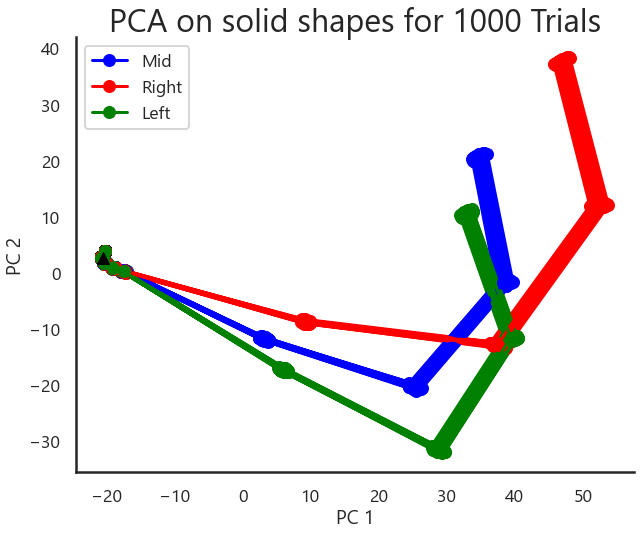

In [88]:
# Plot all trials in ax1, plot fewer trials in ax2
fig, ax = plt.subplots(figsize=(10, 8))
nr = nb = ng = 0

# Go through trials
for t in range(n_trials):

    # Transform each trial
    activity_pc = pca.transform(activity[t])  # (Time points, PCs)

    # Select this trial's ground truth
    trial = trial_infos[t]
    if trial['ground_truth'] == 1:
        motion = 'Right'
        color = 'red'
        nr += 1
    elif trial['ground_truth'] == 2:
        motion = 'Mid'
        color = 'blue'
        nb += 1
    elif trial["ground_truth"] == 3:
        motion = 'Left'
        color='green'
        ng +=1

    # Plot the PC activity
    if (nr == 1 and color == 'red') or (nb == 1 and color == 'blue') or (ng == 1 and color == 'green'):
        _ = ax.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color, label=motion)
    else:
        _ = ax.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color)

    # Plot the beginning of a trial with a special symbol
    _ = ax.plot(activity_pc[0, 0], activity_pc[0, 1], '^', color='black')


plt.legend()
# Change names
ax.set_title(f'PCA on solid shapes for {n_trials} Trials', fontsize=32)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
plt.show()
# save
save_dir = ROOT / "figures" / f"overall_pca_v{model_version}_all_trials_{stim_type}.png"
fig.savefig(str(save_dir))

|Plotting for only 100 trials might look cleaner?

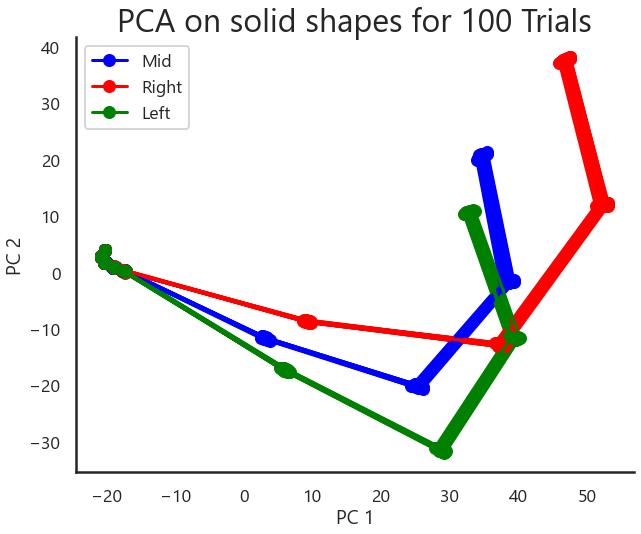

In [89]:
# Plot all trials in ax1, plot fewer trials in ax2
fig, ax = plt.subplots(figsize=(10, 8))
nr = nb = ng = 0

# Go through trials
for t in range(100):

    # Transform each trial
    activity_pc = pca.transform(activity[t])  # (Time points, PCs)

    # Select this trial's ground truth
    trial = trial_infos[t]
    if trial['ground_truth'] == 1:
        motion = 'Right'
        color = 'red'
        nr += 1
    elif trial['ground_truth'] == 2:
        motion = 'Mid'
        color = 'blue'
        nb += 1
    elif trial["ground_truth"] == 3:
        motion = 'Left'
        color='green'
        ng +=1

    # Plot the PC activity
    if (nr == 1 and color == 'red') or (nb == 1 and color == 'blue') or (ng == 1 and color == 'green'):
        _ = ax.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color, label=motion)
    else:
        _ = ax.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color)

plt.legend()
# Change names
ax.set_title(f'PCA on solid shapes for 100 Trials', fontsize=32)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')

# save
save_dir = ROOT / "figures" / f"overall_pca_v{model_version}_100_trials_{stim_type}.png"
fig.savefig(str(save_dir))

## 4. PCA on individual time bins

The idea here is as follows:

1. Bin the activity of each trial by timepoints.
2. Run PCA on each individual bin.
3. Extract PCA loadings.
4. Find the neurons with the highest weight.
5. Visualize the activity of those neurons across timepoints.

In [90]:
# Binning time points
n_timepoints = activity[0].shape[0]
n_bins = 3
bin_size = n_timepoints // n_bins
bins = np.histogram(np.arange(n_timepoints), n_bins)
bin_edges = np.floor(bins[1]).astype(int)
bin_edges

array([0, 3, 6, 9])

In [91]:
# Define PCA with 2 components
n_comps = 2
pca = PCA(n_components=n_comps)

# Initiate variables to keep track of top PCA neurons
n_top = 3  # number of top neurons with the highest weights in PCA
top_neurons = np.zeros((n_comps, n_top, n_bins))

# Loop through time bins
for i, tb in enumerate(bin_edges[:-1]):

    # Select activity across all trials and neurons for only this time bin
    bin_activity = np.concatenate([ac[tb: tb + bin_size] for ac in activity], axis=0)

    # Run PCA
    pca.fit(bin_activity)

    # Extract loadings
    loadings = pca.components_

    # Get index of top k neurons
    for pc in range(n_comps):
        neurons = np.argpartition(loadings[pc], -n_top)[-n_top:]
        top_neurons[pc, :, i] = neurons

In [92]:
top_neurons

array([[[ 14., 105.,  87.],
        [ 39.,  50., 105.],
        [ 98.,  87.,  33.]],

       [[ 60., 105., 112.],
        [ 21.,  87., 100.],
        [ 94.,  64.,  43.]]])

In [93]:
# Gather the data from neurons of interest in a dataframe for easier plotting
data = {"NEURON":[], "TRIAL": [], "TIMEPOINT": [], "ACTIVITY": [], "TRIAL_TYPE": []}

# Find the highest activity neurons (without duplicates)
neurons = np.unique(top_neurons.flatten()).astype(int)

# Get the timeseries of activities
for n, neuron in enumerate(neurons):

    # Find the timeseries of activity of this neuron in all trials
    for trial in range(n_trials):
        for tp in range(n_timepoints):

            ac = activity[trial][tp, neuron]

            # Save to data
            data["NEURON"].append(neuron)
            data["TRIAL"].append(trial + 1)
            data["TIMEPOINT"].append(tp + 1)
            data["ACTIVITY"].append(ac)

            if trial_infos[trial]["ground_truth"] == 1:
                tt = "Right"
            elif trial_infos[trial]["ground_truth"] == 2:
                tt = "Mid"
            else:
                tt = "Left"
            data["TRIAL_TYPE"].append(tt)

# Turn into dataframe
df = pd.DataFrame(data)
df

,NEURON,TRIAL,TIMEPOINT,ACTIVITY,TRIAL_TYPE
0,14,1,1,0.861225,Mid
1,14,1,2,2.079603,Mid
2,14,1,3,4.415073,Mid
3,14,1,4,5.572482,Mid
4,14,1,5,5.890815,Mid
...,...,...,...,...,...
139995,112,1000,6,0.000000,Left
139996,112,1000,7,6.260295,Left
139997,112,1000,8,12.767765,Left
139998,112,1000,9,14.522038,Left


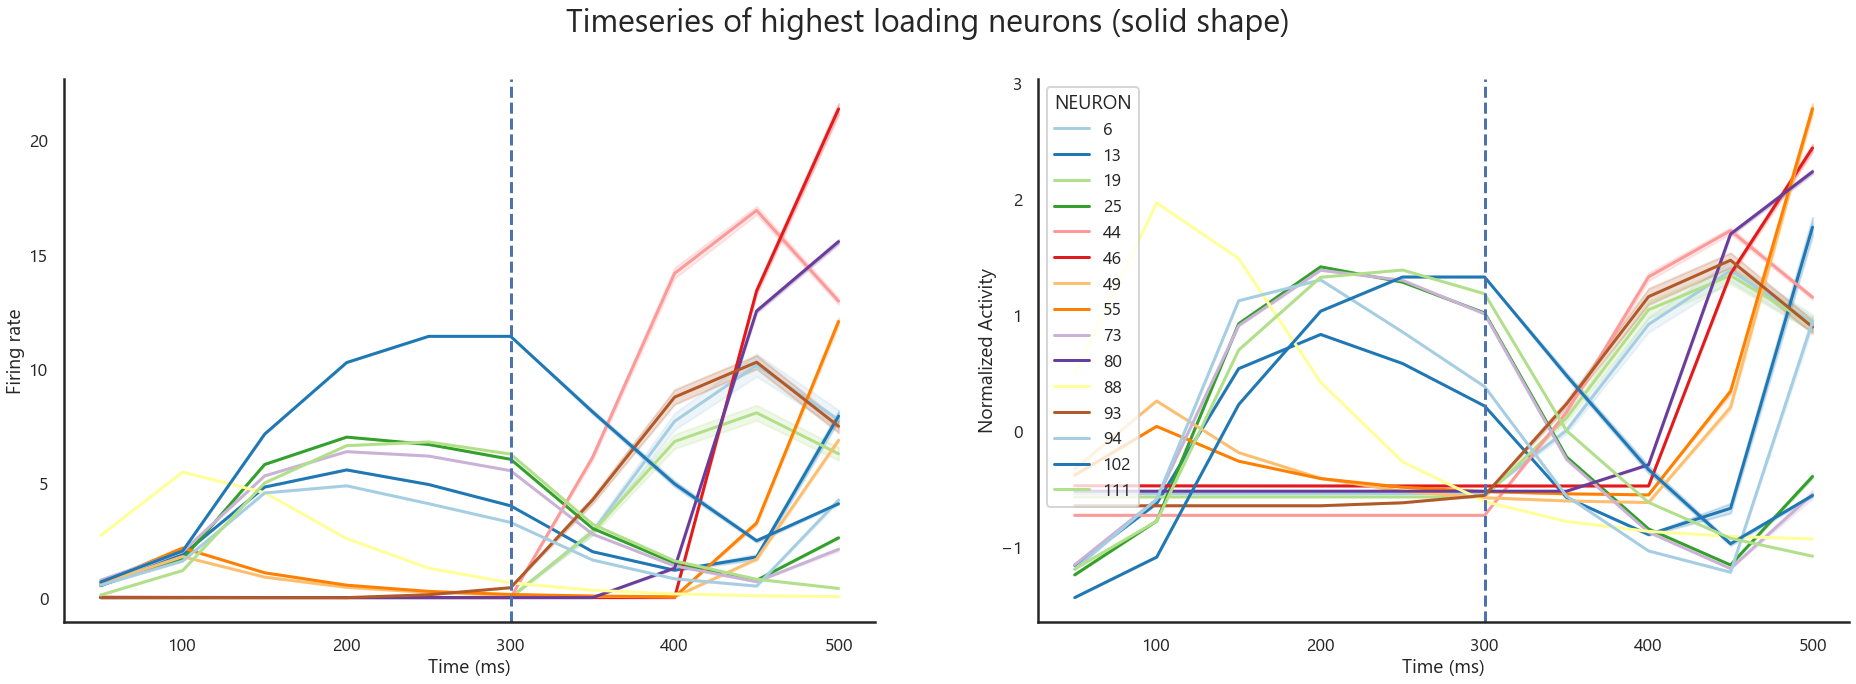

In [72]:
# Visualizing the activity of highest-loading neurons
fig, axes = plt.subplots(1, 2, figsize=(32, 10))
custom_pal = sns.color_palette("Paired", len(df.NEURON.unique()))
fig.suptitle("Timeseries of highest loading neurons (solid shape)", fontsize=32)

# Change title
ax.set_title(f"Timeseries of top PC Neurons")

# Normalize activity
plt_df = df.copy()
for neuron in neurons:
    plt_df.loc[df.NEURON == neuron, "ACTIVITY"] = zscore(plt_df.loc[df.NEURON == neuron, "ACTIVITY"])

# Plot the actual activity
_plot = sns.lineplot(
    data=df,
    x="TIMEPOINT",
    y="ACTIVITY",
    hue="NEURON",
    palette=custom_pal,
    ax=axes[0]
)
axes[0].set_ylabel("Firing rate")
_plot.legend_.remove()

# Plot the normalized activity
_plot = sns.lineplot(
    data=plt_df,
    x="TIMEPOINT",
    y="ACTIVITY",
    hue="NEURON",
    palette=custom_pal,
    ax=axes[1]
)
axes[1].set_ylabel("Normalized Activity")

# Change properties
for i in range(2):
    axes[i].set_xlabel("Time (ms)")
    x_ticks = np.arange(0, 550, 100)
    axes[i].set_xticklabels(x_ticks)
    axes[i].axvline(x=6, color='b', ls='--')

save_dir = ROOT / "figures" / f"highest_activity_{neurons.shape[0]}_neurons_v{model_version}_{stim_type}.png"
fig.savefig(str(save_dir))

Below, I visualize the activity of highest-loading neurons individually based on trial type.

In [73]:
neurons.shape

(15,)

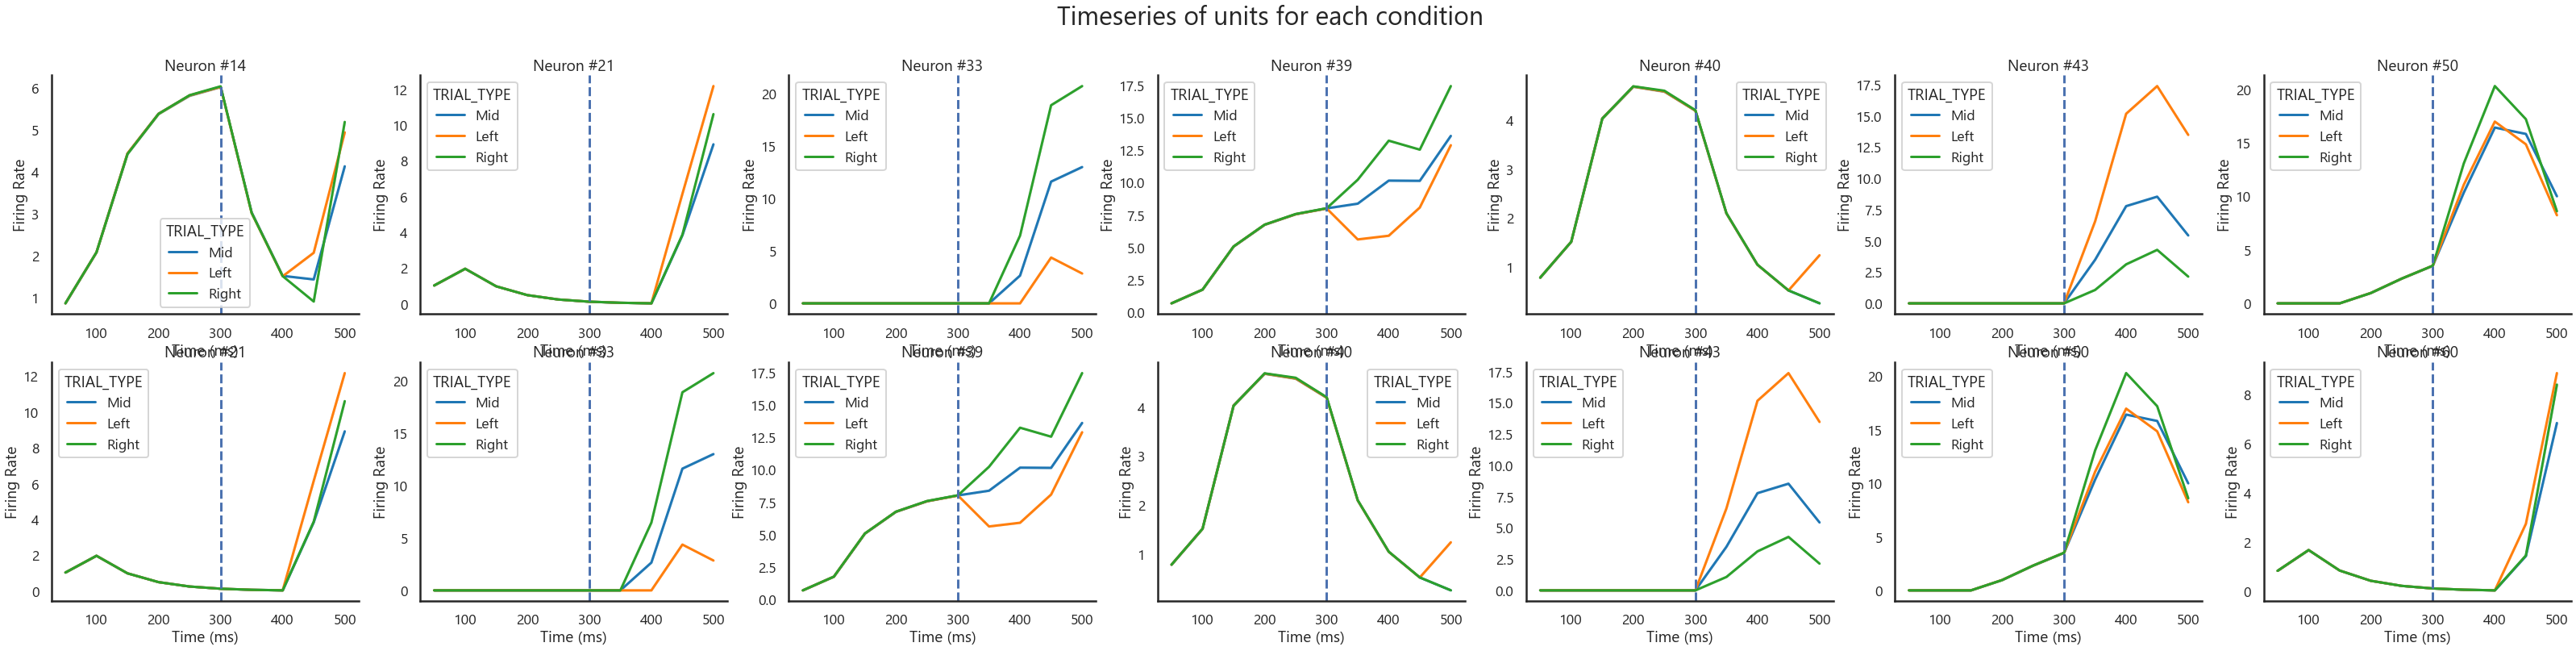

In [44]:
# Visualizing the activity of highest-loading neurons based on
fig, axes = plt.subplots(3, 5, figsize=(56,  12))
custom_pal = sns.color_palette("Paired", 3)
fig.suptitle("Timeseries of units for each condition", fontsize=32)

# Start plotting
n = 0
# for n, neuron in enumerate(neurons):
for i in range(2):
    for j in range(7):

        neuron = neurons[i + j]
        n += 1

        # Select axis
        ax = axes[i][j]

        # Select data and normalize
        _df = df[df.NEURON == neuron]
        # _df.ACTIVITY = zscore(_df.ACTIVITY)

        # Plot
        _plot = sns.lineplot(
            data=_df,
            x="TIMEPOINT",
            y="ACTIVITY",
            hue="TRIAL_TYPE",
            palette='tab10',
            ax=ax
        )

        # Vertical line at the 6th timepoint
        ax.axvline(x=6, color='b', ls='--')

        # Change properties
        ax.set_xlabel("Time (ms)")
        x_ticks = np.arange(0, 550, 100)
        ax.set_xticklabels(x_ticks)

        ax.set_ylabel("Firing Rate")

        ax.set_title(f"Neuron #{neuron}")

save_dir = ROOT / "figures" / f"timecourse_top_{neurons.shape[0]}_neurons_v{model_version}_{stim_type}.png"
fig.savefig(str(save_dir))

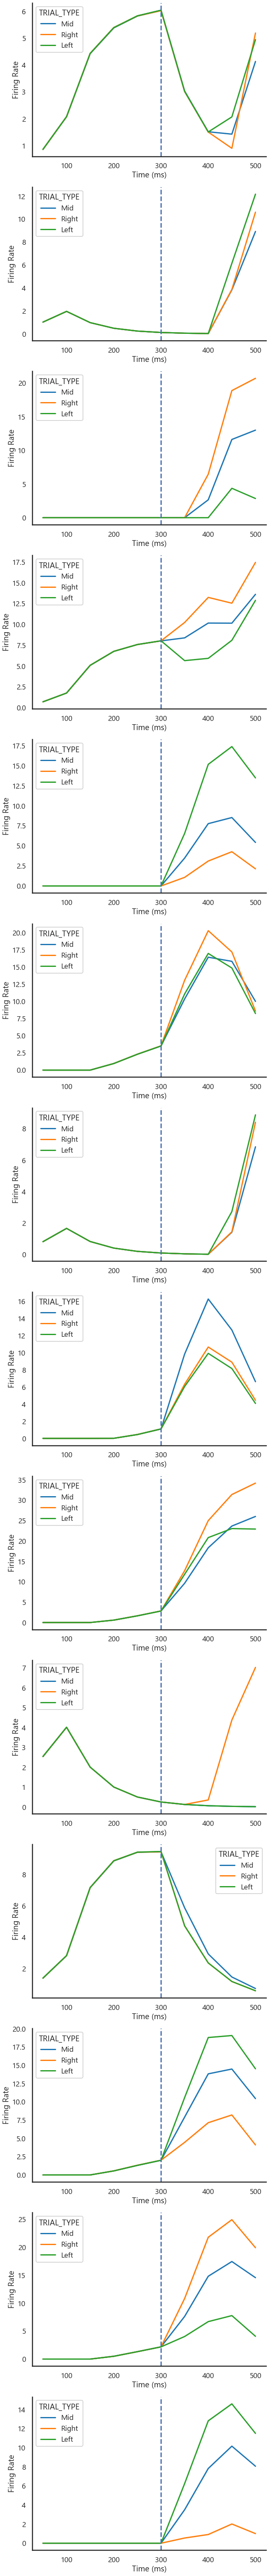

In [94]:
# Visualizing the activity of highest-loading neurons based on
fig, axes = plt.subplots(len(neurons), 1, figsize=(10, 8 * len(neurons)))
custom_pal = sns.color_palette("Paired", 3)

# Start plotting
for n, neuron in enumerate(neurons):

    # Select axis
    ax = axes[n]

    # Select data and normalize
    _df = df[df.NEURON == neuron]
    # _df.ACTIVITY = zscore(_df.ACTIVITY)

    # Plot
    _plot = sns.lineplot(
        data=_df,
        x="TIMEPOINT",
        y="ACTIVITY",
        hue="TRIAL_TYPE",
        palette='tab10',
        ax=ax
    )

    # Vertical line at the 6th timepoint
    ax.axvline(x=6, color='b', ls='--')

    # Change properties
    ax.set_xlabel("Time (ms)")
    x_ticks = np.arange(0, 550, 100)
    ax.set_xticklabels(x_ticks)

    ax.set_ylabel("Firing Rate")

save_dir = ROOT / "figures" / f"timecourse_top_{neurons.shape[0]}_neurons_v{model_version}_{stim_type}.png"
fig.savefig(str(save_dir))

## 5. Representational Similarity Analysis

In [95]:
# Construct a time point by neuron matrix (T, N) but only for times after 300ms (6th time point)
conditions = df.TRIAL_TYPE.unique()
n_conditions = len(conditions)
cutoff = 5
slc_activity = np.zeros((n_conditions, (n_timepoints - cutoff), n_all_neurons))

for trial in range(n_trials):

    ac = activity[trial][cutoff:, :]
    slc_activity[int(trial_infos[trial]["ground_truth"]) - 1, :, :] = ac

# Compute correlation vectors to get (N, N) matrices for each condition
neural_rdms = np.zeros((n_conditions, n_all_neurons, n_all_neurons))

for cond in range(n_conditions):
    for n1 in range(n_all_neurons):
        for n2 in range(n_all_neurons):

            # calculate dissimilarity and save
            neural_rdms[cond, n1, n2] = 1 - np.corrcoef(slc_activity[cond, :, n1], slc_activity[cond, :, n2])[0][1]

# Compute correlation between different conditions (C, C) matrix
condition_rdms = np.zeros((n_conditions, n_conditions))

for c1 in range(n_conditions):
    for c2 in range(n_conditions):

        # select data
        c1_vec = np.tril(1 - neural_rdms[c1, :, :])
        c2_vec = np.tril(1 - neural_rdms[c2, :, :])

        # calculate correlation and save distance
        condition_rdms[c1, c2] = 1 - np.corrcoef(c1_vec, c2_vec)[0][1]

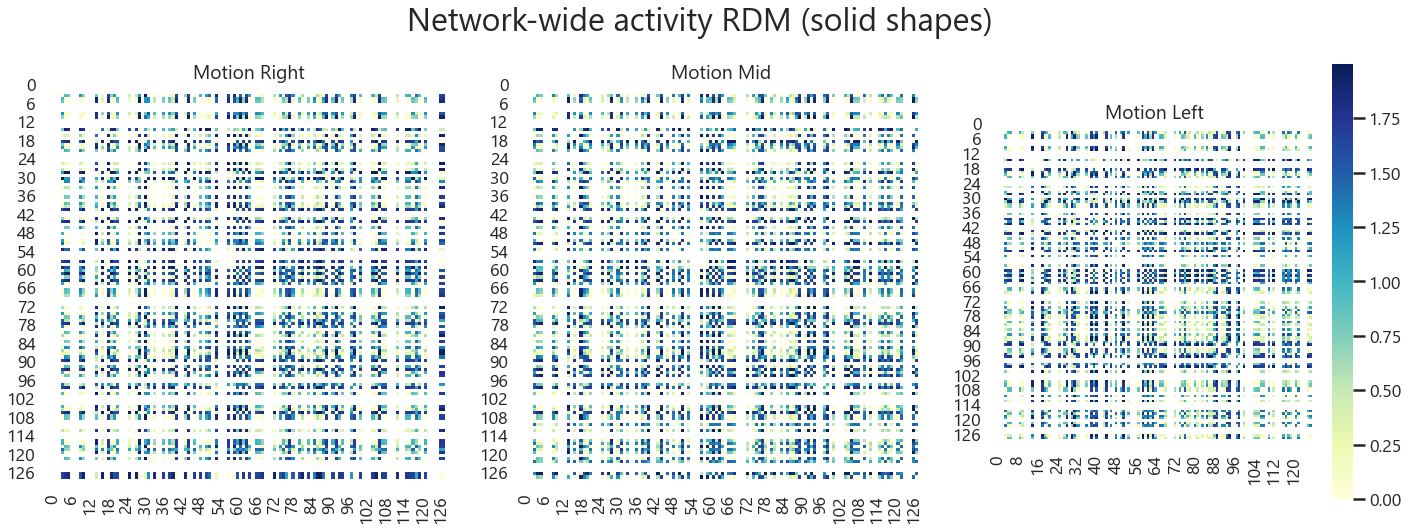

In [96]:
# Plot the neural RDMS
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle("Network-wide activity RDM (solid shapes)", fontsize=32)

for cond in range(n_conditions):

    data = neural_rdms[cond, :, :]
    ax = axes[cond]
    motion = 'Right' if cond == 0 else ('Mid' if cond == 1 else 'Left')
    ax.set_title(f"Motion {motion}")

    # plot
    _plot = sns.heatmap(
        data=data,
        # linewidths=.1,
        # linecolor='black',
        cbar=True if cond == 2 else False,
        square=True,
        cmap="YlGnBu",
        center=1,
        # vmin=1,
        # vmax=2,
        ax=ax
    )


save_dir = ROOT / "figures" / f"RDMS_all_neurons_v{model_version}_{stim_type}.png"
fig.savefig(str(save_dir))

In [97]:
# Construct a time point by neuron matrix (T, N) but only for times after 300ms (6th time point)
conditions = df.TRIAL_TYPE.unique()
n_conditions = len(conditions)
n_neurons = len(neurons)
cutoff = 5
slc_activity = np.zeros((n_conditions, (n_timepoints - cutoff), n_neurons))

for trial in range(n_trials):
    for n, neuron in enumerate(neurons):
        ac = activity[trial][cutoff:, neuron]
        ac = zscore(ac, axis=0, ddof=1)
        slc_activity[int(trial_infos[trial]["ground_truth"]) - 1, :, n] = ac

# Compute correlation vectors to get (N, N) matrices for each condition
neural_rdms = np.zeros((n_conditions, n_neurons, n_neurons))

for cond in range(n_conditions):
    # calculate dissimilarity and save
    neural_rdms[cond, :, :] = 1 - spearmanr(slc_activity[cond, :, :])[0]

# Compute correlation between different conditions (C, C) matrix
condition_corrs = np.array([(1 - neural_rdms[c, :, :][np.triu_indices(n_neurons, k=1)]) for c in range(n_conditions)]).T
condition_corrs = condition_corrs[~np.isnan(condition_corrs).any(axis=1)]
condition_rdm = 1 - spearmanr(condition_corrs)[0]

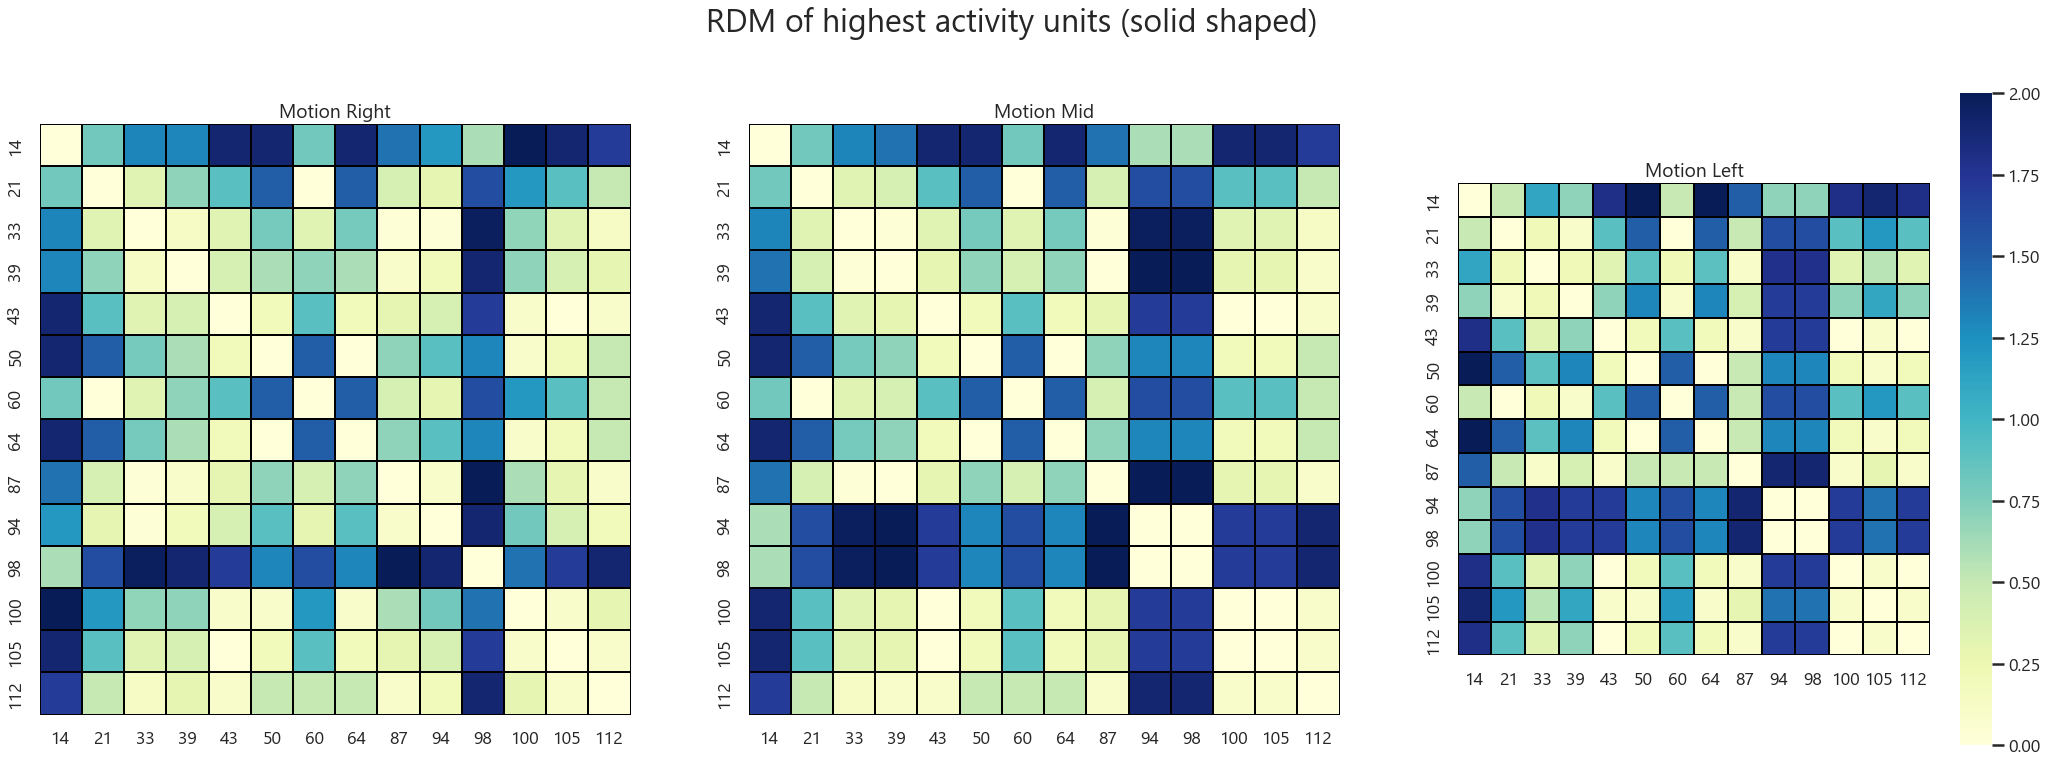

In [98]:
# Plot the neural RDMS
fig, axes = plt.subplots(1, 3, figsize=(36, 12))
fig.suptitle("RDM of highest activity units (solid shaped)", fontsize=32)

for cond in range(n_conditions):

    data = neural_rdms[cond, :, :]
    ax = axes[cond]
    motion = 'Right' if cond == 0 else ('Mid' if cond == 1 else 'Left')
    ax.set_title(f"Motion {motion}")

    # plot
    _plot = sns.heatmap(
        data=data,
        linewidths=.005,
        linecolor='black',
        cbar=True if cond == 2 else False,
        square=True,
        cmap="YlGnBu",
        center=1,
        # vmin=1,
        # vmax=2,
        ax=ax,
        xticklabels=neurons,
        yticklabels=neurons
    )

save_dir = ROOT / "figures" / f"RDMS_{n_neurons}_neurons_v{model_version}_{stim_type}.png"
fig.savefig(str(save_dir))

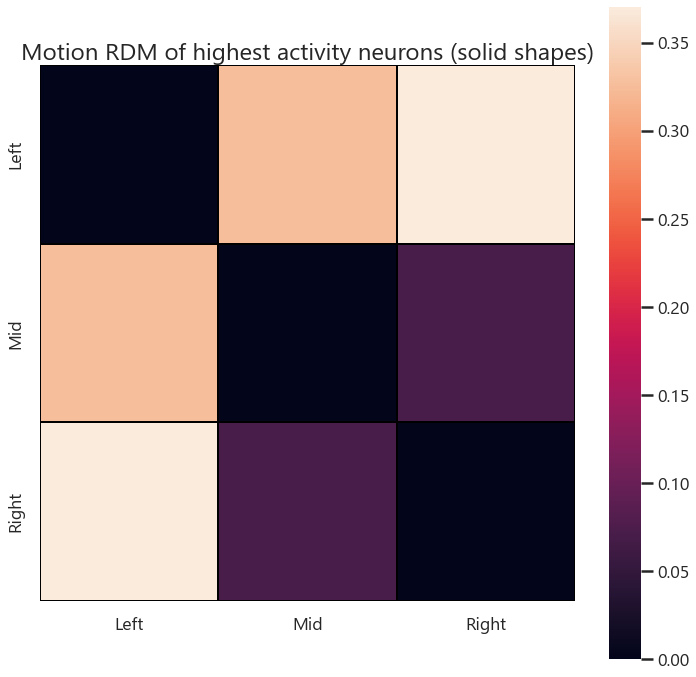

In [99]:
# Plot the neural RDMS
fig, ax = plt.subplots(figsize=(12, 12))
condition_names = ["Left", "Mid", "Right"]

# plot
_plot = sns.heatmap(
    data=condition_rdm,
    linewidths=.1,
    linecolor='black',
    square=True,
    # cmap="YlGnBu",
    ax=ax,
    xticklabels=condition_names,
    yticklabels=condition_names
)

ax.set_title("Motion RDM of highest activity neurons (solid shapes)", fontsize=24)
save_dir = ROOT / "figures" / f"motion_RDM_{n_neurons}_neurons_v{model_version}_{stim_type}.png"
fig.savefig(str(save_dir))

In [100]:
# Construct a time point by neuron matrix (T, N) but only for times after 300ms (6th time point)
conditions = df.TRIAL_TYPE.unique()
n_conditions = len(conditions)
n_neurons = len(neurons)
cutoff = 5
slc_activity = np.zeros((n_conditions, (n_timepoints - cutoff), n_neurons))

for trial in range(n_trials):

    ac = activity[trial][cutoff:, :]
    slc_activity[int(trial_infos[trial]["ground_truth"]) - 1, :, :] = ac

# Compute correlation vectors to get (N, N) matrices for each condition
neural_rdms = np.zeros((n_conditions, n_neurons, n_neurons))

for cond in range(n_conditions):
    for n1, neu1 in enumerate(neurons):
        for n2, neu2 in enumerate(neurons):

            # calculate dissimilarity and save
            neural_rdms[cond, n1, n2] = 1 - np.corrcoef(slc_activity[cond, :, neu1], slc_activity[cond, :, n2])[0][1]

# Compute correlation between different conditions (C, C) matrix
condition_rdms = np.zeros((n_conditions, n_conditions))

for c1 in range(n_conditions):
    for c2 in range(n_conditions):

        # select data
        c1_vec = np.tril(1 - neural_rdms[c1, :, :])
        c2_vec = np.tril(1 - neural_rdms[c2, :, :])

        # calculate correlation and save distance
        condition_rdms[c1, c2] = 1 - np.corrcoef(c1_vec, c2_vec)[0][1]

ValueError: could not broadcast input array from shape (5,128) into shape (5,14)

## 6. Input analysis

In [ ]:
activity[0][:, neurons[0]]

## TODO

- Look at interesting neurons' weights and inputs
- Remove mean from plots
- Time point 6
- RSA distance for 3 conditions for the last bin, or at all time bins